In [115]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [69]:
# Load dataset
salary = pd.read_csv('Experience-Salary.csv')

In [114]:
# Data Exploration
salary.shape
salary.info()
salary.describe()
salary.sample(100)
salary.head(100)
salary.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Experience  1000 non-null   float64
 1   Salary      1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


,Experience,Salary
995,22.161741,24.666502
996,32.266497,24.160270
997,17.039030,19.903797
998,25.222124,21.974413
999,16.418028,19.634787


In [71]:
# Rename columns
salary = salary.rename(columns={'exp(in months)': 'Experience','salary(in thousands)': 'Salary'})

In [72]:
# Data Cleaning
salary.isnull().sum()
salary.duplicated().sum()
salary.drop_duplicates(inplace=True)
salary.dropna(inplace=True)

,Experience,Salary
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236
...,...,...
995,22.161741,24.666502
996,32.266497,24.160270
997,17.039030,19.903797
998,25.222124,21.974413


In [73]:
# Define Target and Feature
X = salary[['Experience']] # Feature
y = salary['Salary'] # target

In [74]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [75]:
# Create model and train it
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
# make predictions
y_predictions = model.predict(X_test)
#print(f'Predictions: {predictions}')

In [84]:
# Evaluate model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_predictions)
print(f'Mean Square Error: {mse}')
accuracy = r2_score(y_test,y_predictions)
print(f'Accuray Score: {accuracy}')

Mean Square Error: 27.84943126858934
Accuray Score: 0.6577354458298199


In [85]:
# Check model equations
print(f'Slope of (m): {model.coef_}')
print(f'Intercept of (b): {model.intercept_}')

Slope of (m): [0.81843038]
Intercept of (b): 5.121312829369433


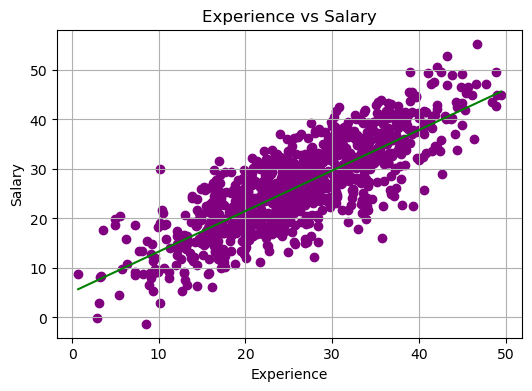

In [113]:
# Visualise graph
X_sorted = X.sort_values(by='Experience')
y_sorted_pred = model.predict(X_sorted)
plt.figure(figsize=(6,4))
plt.scatter(X,y,color='purple')
plt.plot(X_sorted,y_sorted_pred,color='green')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.grid()
plt.show()

In [112]:
# Predict New Value
print('New Value',model.predict(np.array([[20]])))

New Value [21.48992052]


C:\Users\EASY BUSINESS TECH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [116]:
# save model
joblib.dump(model, "model.pkl")

['model.pkl']